Name: Sakshi Jadhav  
Roll No.: EN23107043   
Department: AIDS-A  
Subject: AI-PD  

<h3>ASSIGNMENT NO-03</h3>

Dataset: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("imdb.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>','', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(clean_text)

In [7]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

Text(0, 0.5, 'Number of Reviews')

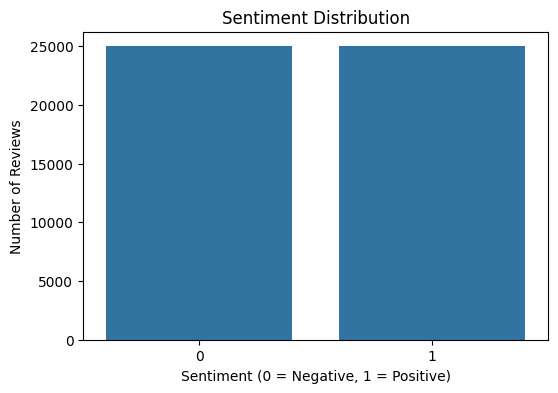

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [10]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
print("Naive Bayes")

print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Precision:", precision_score(y_test, pred_nb))
print("Recall:", recall_score(y_test, pred_nb))
print("F1 Score:", f1_score(y_test, pred_nb))

Naive Bayes
Accuracy: 0.8552
Precision: 0.8533753198189333
Recall: 0.8604881921016074
F1 Score: 0.8569169960474309


In [11]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Logistic Regression
Accuracy: 0.8924
Precision: 0.8824551244933411
Recall: 0.9073228815241119
F1 Score: 0.8947162426614481


In [12]:
svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM")

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1 Score:", f1_score(y_test, pred_svm))

SVM
Accuracy: 0.8823
Precision: 0.8756809338521401
Recall: 0.8932327842825958
F1 Score: 0.8843697809215051


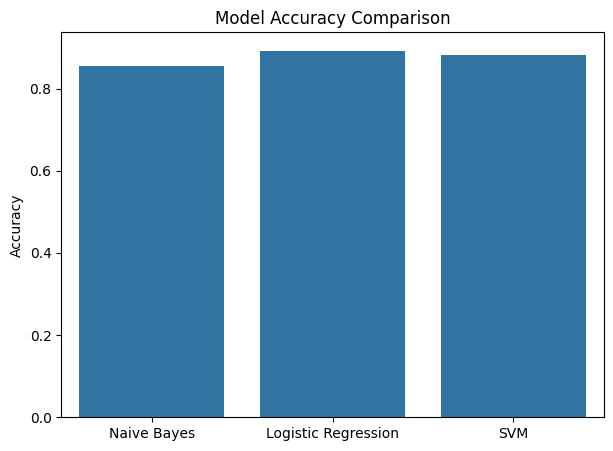

In [13]:
models = ['Naive Bayes','Logistic Regression','SVM']
accuracies = [
    accuracy_score(y_test, pred_nb),
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_svm)
]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

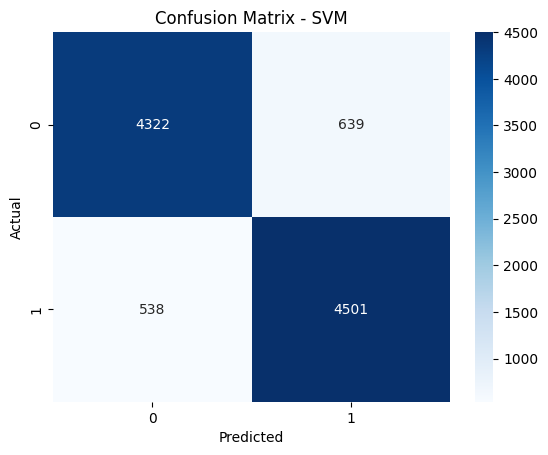

In [14]:
cm = confusion_matrix(y_test, pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [15]:
review = input("Enter the review: ")
clean = clean_text(review)
vector = vectorizer.transform([clean])
prediction = svm.predict(vector)
if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Enter the review:  This movie was awesome!


Positive Review


In [16]:
review = input("Enter the review: ")
clean = clean_text(review)
vector = vectorizer.transform([clean])
prediction = svm.predict(vector)
if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Enter the review:  The movie was boring and the actions were too slow...


Negative Review
